# Altın Oran Arama Yöntemi (Golden Section Search)

Altın Oran Arama Yöntemi, tek tepeli (unimodal) bir fonksiyonun belirli bir kapalı aralıkta minimum noktasını bulmak için kullanılan türevsiz bir optimizasyon yöntemidir.  

Yöntem, aralığı her iterasyonda sabit bir oranla küçülterek minimum noktaya yaklaşır.

---

## Altın Oran Sabiti

Altın oran sabiti:

$$
\phi = \frac{\sqrt{5} - 1}{2}
$$

Yaklaşık değeri:

$$
\phi \approx 0.618
$$

---

## Başlangıç Aralığı

Başlangıçta minimumun bulunduğu düşünülen bir aralık seçilir:

$$
[a, b]
$$

Bu çalışmada kullanılan başlangıç aralığı:

$$
a = 1, \quad b = 2.5
$$

Tolerans değeri:

$$
tol = 0.01
$$

---

## Ara Noktaların Hesaplanması

Her iterasyonda iki iç nokta hesaplanır:

$$
d = \phi (b - a)
$$

$$
x_1 = b - d
$$

$$
x_2 = a + d
$$

---

## Karar Mekanizması

Fonksiyon değerleri karşılaştırılır:

- Eğer

$$
f(x_1) < f(x_2)
$$

ise yeni aralık:

$$
[a, x_2]
$$

- Aksi halde yeni aralık:

$$
[x_1, b]
$$

şeklinde güncellenir.

---

## Durdurma Kriteri

Algoritma aşağıdaki koşul sağlanana kadar devam eder:

$$
(b - a) \leq tol
$$

Minimum nokta yaklaşık olarak:

$$
x^* = \frac{a + b}{2}
$$

şeklinde hesaplanır.

---

# Test Fonksiyonları

## 1) Polinom Fonksiyon

$$
f(x) = x^4 - 4x^2 + x
$$

Başlangıç aralığı:

$$
[1, 2.5]
$$

---

## 2) Tam Kare Fonksiyon

$$
f(x) = x^2 + 10x + 25
$$

Bu fonksiyon şu şekilde yazılabilir:

$$
f(x) = (x + 5)^2
$$

Minimum noktası:

$$
x = -5
$$

Başlangıç aralığı:

$$
[-10, 0]
$$

---

## 3) Görselleştirme İçin Kullanılan Fonksiyon

$$
f(x) = (x - 3)^2 + 2
$$

Başlangıç aralığı:

$$
[1, 5]
$$

Tolerans:

$$
tol = 1
$$

---

# Yöntemin Özellikleri

- Türev gerektirmez.
- Tek minimumlu (unimodal) fonksiyonlarda etkilidir.
- Her iterasyonda aralık yaklaşık olarak

$$
0.618 \times (b - a)
$$

oranında küçülür.
- Yaklaşık iterasyon sayısı:

$$
O\left(\log \frac{b-a}{tol}\right)
$$


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import math

In [17]:
a = 1
b = 2.5
tol = 0.01  

while (b - a > tol):
    
    d = 0.618 * (b - a)
    x1 = b - d
    x2 = a + d
    
    if f(x1) < f(x2):
        b = x2
    else: 
        a = x1
        
    print(f"Yeni aralık: [{a:.4f}, {b:.4f}]")

final_x = (a + b) / 2
print(f"Minimum Nokta Yaklaşık: {final_x:.4f}")

Yeni aralık: [1.0000, 1.9270]
Yeni aralık: [1.0000, 1.5729]
Yeni aralık: [1.0000, 1.3540]
Yeni aralık: [1.0000, 1.2188]
Yeni aralık: [1.0000, 1.1352]
Yeni aralık: [1.0000, 1.0836]
Yeni aralık: [1.0000, 1.0516]
Yeni aralık: [1.0000, 1.0319]
Yeni aralık: [1.0000, 1.0197]
Yeni aralık: [1.0000, 1.0122]
Yeni aralık: [1.0000, 1.0075]
Minimum Nokta Yaklaşık: 1.0038


In [18]:
def altin_oran_op(f, a, b, tol=1e-5):
    phi = (math.sqrt(5) - 1) / 2
    d = phi * (b - a)
    x1 = b - d
    x2 = a + d

    while (b - a) > tol:
        if f(x1) < f(x2):
             
            b = x2
            x2 = x1  
            d = phi * (b - a)
            x1 = b - d
        else:
             
            a = x1
            x1 = x2   
            d = phi * (b - a)
            x2 = a + d
    return (a + b) / 2

 
def test_fonksiyonu(x):
    return x**4 - 4*x**2 + x

 
baslangic_a = 1
bitis_b = 2.5
sonuc = altin_oran_op(test_fonksiyonu, baslangic_a, bitis_b)

print(f"Bulunan Minimum Nokta: {sonuc:.6f}")
print(f"O noktadaki fonksiyon değeri: {test_fonksiyonu(sonuc):.6f}")

Bulunan Minimum Nokta: 1.346998
O noktadaki fonksiyon değeri: -2.618556


In [19]:
def f(x):
    return x**2 + 10*x + 25

başlangıç_a = -10
bitiş_b = 0

sonuç = altin_oran_op(f, başlangıç_a, bitiş_b)
print(f"Bulunan Minimum Nokta: {sonuç:.6f}")
print(f"O noktadaki fonksiyon değeri: {f(sonuç):.6f}")


Bulunan Minimum Nokta: -5.000002
O noktadaki fonksiyon değeri: 0.000000


In [20]:
def altin_oran(f, a, b, tol=1e-5):
    phi = (math.sqrt(5) - 1) / 2
    d = phi * (b - a)
    x1 = b - d
    x2 = a + d
 
    x_ekseni = np.linspace(a - 0.5, b + 0.5, 400)
    y_ekseni = [f(i) for i in x_ekseni]
    
    iterasyon = 0
    while (b - a) > tol:
        iterasyon += 1
         
        plt.clf()
        plt.plot(x_ekseni, y_ekseni, 'k-', label='f(x)')
        plt.axvspan(a, b, color='yellow', alpha=0.2, label='Güncel Aralık')
        plt.plot([x1, x2], [f(x1), f(x2)], 'ro')
        plt.title(f"İterasyon: {iterasyon} | Aralık Genişliği: {(b-a):.4f}")
        plt.legend()
        plt.pause(0.5)  
        
        if f(x1) < f(x2):
            b = x2
            x2 = x1
            d = phi * (b - a)
            x1 = b - d
        else:
            a = x1
            x1 = x2
            d = phi * (b - a)
            x2 = a + d
            
    plt.show()
    return (a + b) / 2

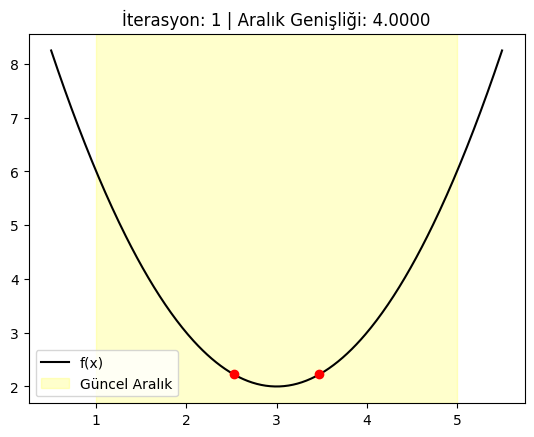

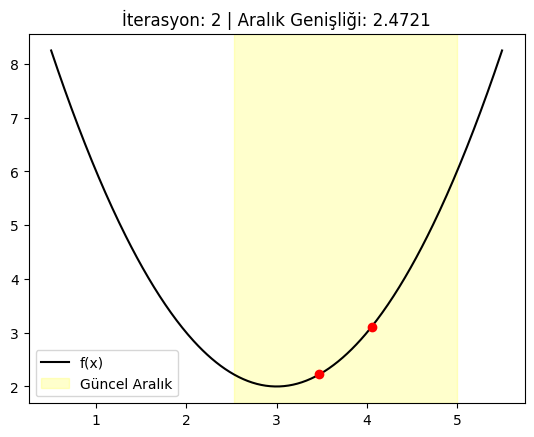

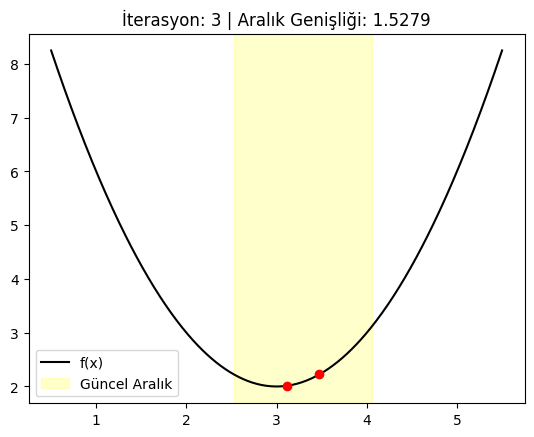

In [21]:
def fonk(x):
    return (x - 3)**2 + 2

sonuc = altin_oran(fonk, 1, 5, tol=1)